In [1]:
import pandas as pd

In [24]:
dataset = pd.read_csv("loan_sanction_test-selected-columns.csv")

In [25]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0


In [26]:
dataset.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
dtype: int64

In [27]:
dataset.dropna()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0
...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0


In [28]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
dtypes: float64(2), int64(2), str(6)
memory usage: 28.8 KB


In [29]:
quan = [col for col in dataset if dataset[col].dtype in ['int64', 'float64']]
qual = [col for col in dataset if dataset[col].dtype in ['object', 'category', 'string']]

In [30]:
quan

['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

In [31]:
import numpy as np
descriptive = pd.DataFrame(index = ["Mean","Median","Mode","Percentile100","Percentile99","Percentile25","Percentile75","IQR","LowerIQR","GreaterIQR","Min","Max","Skewn","Kurt","vari","sd"], columns = quan)
for columnName in quan:
    descriptive.loc["Mean",columnName] = dataset[columnName].mean()
    descriptive.loc["Median",columnName] = dataset[columnName].median()
    descriptive.loc["Mode",columnName] = dataset[columnName].mode().iloc[0]
    descriptive.loc["Percentile100",columnName] = np.percentile(dataset[columnName],100)
    descriptive.loc["Percentile99",columnName] = np.percentile(dataset[columnName],99)
    descriptive.loc["Percentile25",columnName] = dataset.describe()[columnName]["25%"]
    descriptive.loc["Percentile75",columnName] = dataset.describe()[columnName]["75%"]
    descriptive.loc["IQR",columnName] = dataset.describe()[columnName]["75%"] - dataset.describe()[columnName]["25%"]
    descriptive.loc["LowerIQR",columnName] = dataset.describe()[columnName]["25%"] - (1.5 * (dataset.describe()[columnName]["75%"] - dataset.describe()[columnName]["25%"]) )
    descriptive.loc["GreaterIQR",columnName] = dataset.describe()[columnName]["75%"] + (1.5 * (dataset.describe()[columnName]["75%"] - dataset.describe()[columnName]["25%"]) )
    descriptive.loc["Min",columnName] = dataset[columnName].min()
    descriptive.loc["Max",columnName] = dataset[columnName].max()
    descriptive.loc["Skewn",columnName] = dataset[columnName].skew()
    descriptive.loc["Kurt",columnName] = dataset[columnName].kurtosis()
    descriptive.loc["vari",columnName] = dataset[columnName].var()
    descriptive.loc["sd",columnName] = dataset[columnName].std()

In [32]:
descriptive

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
Mean,4805.599455,1569.577657,136.132597,342.537396
Median,3786.0,1025.0,125.0,360.0
Mode,3500,0,150.0,360.0
Percentile100,72529.0,24000.0,NaN,NaN
Percentile99,20865.38,12453.78,NaN,NaN
Percentile25,2864.0,0.0,100.25,360.0
Percentile75,5060.0,2430.5,158.0,360.0
IQR,2196.0,2430.5,57.75,0.0
LowerIQR,-430.0,-3645.75,13.625,360.0
GreaterIQR,8354.0,6076.25,244.625,360.0


In [33]:
freqTable = pd.DataFrame(columns=["uniq_val","Freq","relative_freq","cummu_freak"])
freqTable["uniq_val"]=dataset["LoanAmount"].value_counts().index
freqTable["Freq"]=dataset["LoanAmount"].value_counts().values
freqTable["relative_freq"]=(freqTable["Freq"]/314)
freqTable["cummu_freak"]=freqTable["relative_freq"].cumsum()

In [34]:
freqTable

,uniq_val,Freq,relative_freq,cummu_freak
0,150.0,12,0.038217,0.038217
1,125.0,11,0.035032,0.073248
2,110.0,10,0.031847,0.105096
3,100.0,9,0.028662,0.133758
4,90.0,9,0.028662,0.162420
...,...,...,...,...
139,197.0,1,0.003185,1.140127
140,85.0,1,0.003185,1.143312
141,60.0,1,0.003185,1.146497
142,76.0,1,0.003185,1.149682


In [35]:
lowerir = []
greaterir = []

for col in quan:
    # Use .loc[row, col] and pass the variable 'col' without quotes
    if descriptive.loc["Min", col] < descriptive.loc["LowerIQR", col]:
        lowerir.append(col)
        
    if descriptive.loc["Max", col] > descriptive.loc["GreaterIQR", col]:
        greaterir.append(col)

print("Columns with Lower Outliers:", lowerir)
print("Columns with Greater Outliers:", greaterir)

Columns with Lower Outliers: ['Loan_Amount_Term']
Columns with Greater Outliers: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']


In [36]:
def low_remover(lowerir,descriptive,dataset):
    for i in lowerir:
        lower_limit = descriptive.loc["LowerIQR", i]
        dataset.loc[dataset[i] < lower_limit,i] = lower_limit

In [37]:
low_remover(lowerir,descriptive,dataset)

In [38]:
print("New min :", dataset["Loan_Amount_Term"].min())

New min : 360.0


In [39]:
def greater_remover(greaterir,descriptive,dataset):
    for i in greaterir:
        greater_limit = int(descriptive.loc["GreaterIQR", i])
        dataset.loc[dataset[i] > greater_limit,i] = greater_limit

In [40]:
greater_remover(greaterir,descriptive,dataset)

In [41]:
print("New max :", dataset["Loan_Amount_Term"].max())

New max : 360.0


In [42]:
from matplotlib import pyplot
from scipy.stats import norm
import seaborn as sns
def get_pdf_prob(dataset,start,end):
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(start,color='Red')
    pyplot.axvline(end,color='Red')
    sample = dataset
    sample_mean = sample.mean()
    sample_std = sample.std()
    print("sample mean:",sample_mean)
    print("sample sd:",sample_std)
    dist = norm(sample_mean,sample_std)
    values = [value for value in range(start,end)]
    probab = [dist.pdf(value) for value in values]
    prob = sum(probab)
    return prob

C:\Users\hemav\AppData\Local\Temp\ipykernel_6588\3455478770.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


sample mean: 4238.964577656676
sample sd: 1950.9763567617802


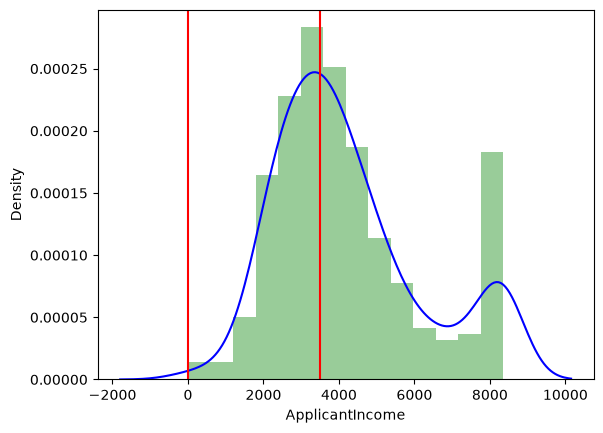

In [43]:
probability = get_pdf_prob(dataset['ApplicantIncome'], 0, 3500)

In [44]:
def stdNBgraph(dataset):
    mean = dataset.mean()
    std = dataset.std()
    values = [i for i in dataset]
    z_score = [((j-mean)/std) for j in values]
    sns.distplot(z_score,kde=True)
    sum(z_score)/len(z_score)

C:\Users\hemav\AppData\Local\Temp\ipykernel_6588\3865492358.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


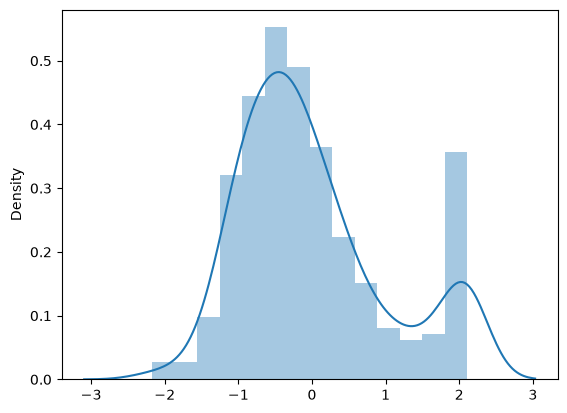

In [45]:
stdNBgraph(dataset['ApplicantIncome'])